# Dive Into Deep Learning

## 1. Introduction
[GitHub Repository](https://github.com/d2l-ai/d2l-en/tree/master/d2l) | [Book](https://d2l.ai/)

### 1.1 Preparing environment

In [1]:
import collections
import hashlib
import inspect
import math
import os
import random
import re
import shutil
import sys
import tarfile
import time
import zipfile
import pandas as pd
import requests

from collections import defaultdict
from IPython import display
from matplotlib import pyplot as plt
from matplotlib_inline import backend_inline
from urllib.error import HTTPError, URLError
from numpy.testing import assert_array_equal

In [2]:
import numpy as np
import torch
import torchvision

from PIL import Image
from scipy.spatial import distance_matrix
from torch import nn
from torch.nn import functional as F
from torchvision import transforms
from torch.distributions.multinomial import Multinomial
from d2l import d2ltorch as d2l

In [3]:
%matplotlib inline

In [4]:
# Global variables
CRED = '\033[41m'
CEND = '\033[0m'

### 1.2 Kinds of Machine Learning Problems

- **Supervised Learning**
    * **Regression**:
      When labels take on arbitrary numerical values (even within some interval), we call this a regression problem.
      It focus on minimizing the **squared error loss** function.
    * **Classification**:
      The common loss function for classification problems is called **cross-entropy**.
        - **Binary Classification**: The simplest form of classification is when there are only two classes, a problem
          which we call binary classification.
        - **Multiclass Classification**: When we have more than two possible classes, we call the problem multiclass
          classification.
        - **Hierarchical Classification**: When some variants of classification addressing hierarchically structured classes.
    * **Tagging**:
      The problem of learning to predict classes that are not mutually exclusive is called **multi-label classification**.
      **Auto-tagging** problems are typically best described in terms of multi-label classification.
    * **Search**:
      The goal is less to determine whether a particular page is relevant for a query, but rather which, among a set
      of relevant results, should be shown most prominently to a particular user.
    * **Recommender Systems**:
      Recommender systems are another problem setting that is related to search and ranking.
      The problems are similar insofar as the goal is to display a set of items relevant to the user.
      The main difference is the emphasis on personalization to specific users in the context of recommender systems.
    * **Sequence Learning**:
      They require a model either to ingest sequences of inputs or to emit sequences of outputs (or both).
      Specifically, sequence-to-sequence learning considers problems where both inputs and outputs consist of
      variable-length sequences.
      Some relevant types of sequence:
        - **Tagging and Parsing**: This involves annotating a text sequence with attributes.
        - **Automatic Speech Recognition**: With speech recognition, the input sequence is an audio recording of a speaker,
          and the output is a transcript of what the speaker said. The output is much shorter than the input.
        - **Text to Speech**: This is the inverse of automatic speech recognition. Here, the input is text and the output
          is an audio file. In this case, the output is much longer than the input.
        - **Machine Translation**: Here the input and output sequences can have different lengths, and the corresponding
          regions of the respective sequences may appear in a different order.
- **Unsupervised and Self-Supervised Learning**
    * **Clustering**: Ex. given a collection of users’ browsing activities, can we group them into users with similar behavior?
    * **Subspace Estimation**. If the dependence is linear, it is called **Principal Component Analysis**.
      Main goal: Can we find a small number of parameters that accurately capture the relevant properties of the data?
      Ex. The trajectories of a ball are well described by velocity, diameter, and mass of the ball.
    * **Euclidean space**: Is there a representation of (arbitrarily structured) objects in Euclidean space such that symbolic
      properties can be well matched? This can be used to describe entities and their relations, such as “Rome” → “Italy”,
      “France” → “Paris”.
    * **Causality and Probabilistic Graphical Models**: Is there a description of the root causes of much of the data that we
      observe? For instance, if we have demographic data about house prices, pollution, crime, location, education, and
      salaries, can we discover how they are related simply based on empirical data?
    * **Deep Generative Models**: These models estimate the density of the data, either explicitly or implicitly.
      Once trained, we can use a generative model either to score examples according to how likely they are, or to sample
      synthetic examples from the learned distribution.
- **Reinforcement Learning**: Reinforcement learning gives a very general statement of a problem in which an agent interacts
  with an environment over a series of time steps. At each time step, the agent receives some observation from the environment
  and must choose an action that is subsequently transmitted back to the environment via some mechanism (sometimes called an
  actuator), when, after each loop, the agent receives a reward from the environment.
    * **Markov Decision Process**: When the environment is fully observed.
    * **Contextual Bandit Problem**: When the state does not depend on the previous actions.
    * **Multi-Armed Bandit Problem**:  When there is no state, just a set of available actions with initially unknown rewards.

Some types of **Deep Learning**:
- **Multilayer perceptrons** (McCulloch and Pitts, 1943)
- **Convolutional neural networks** (LeCun et al., 1998)
- **Long short-term memory** (Hochreiter and Schmidhuber, 1997)
- **Q-Learning** (Watkins and Dayan, 1992)

Usefull methods:
- **Dropout** (Srivastava et al., 2014), have helped to mitigate overfitting.
- **Learning rate** - learnable pointer structure (Bahdanau et al., 2014) to increase the memory and complexity of a system without increasing the number of learnable parameters.
- **Transformer architecture** (Vaswani et al., 2017) has demonstrated superior scaling behavior: it performs better with an increase in dataset size, model size, and amount of training compute (Kaplan et al., 2020). This architecture has demonstrated compelling success in a wide range of areas, such as natural language processing (Brown et al., 2020, Devlin et al., 2018), computer vision (Dosovitskiy et al., 2021, Liu et al., 2021), speech recognition (Gulati et al., 2020), reinforcement learning (Chen et al., 2021), and graph neural networks (Dwivedi and Bresson, 2020).
- Modeling probabilities of text sequences, language models can predict text given other text. **Scaling up** the data, model, and compute has unlocked a growing number of capabilities of language models to perform desired tasks via human-like text generation based on input text (Anil et al., 2023, Brown et al., 2020, Chowdhery et al., 2022, Hoffmann et al., 2022, OpenAI, 2023, Rae et al., 2021, Touvron et al., 2023a, Touvron et al., 2023b).
- Multi-stage designs, e.g., via the **memory networks** (Sukhbaatar et al., 2015) and the **neural programmer-interpreter** (Reed and De Freitas, 2015) permitted statistical modelers to describe iterative approaches to reasoning.
- A key development in deep generative modeling was the invention of **generative adversarial networks** (Goodfellow et al., 2014). Traditionally, statistical methods for density estimation and generative models focused on finding proper probability distributions and (often approximate) algorithms for sampling from them.
- A key development in deep generative modeling was the invention of **generative adversarial networks** (Goodfellow et al., 2014). Traditionally, statistical methods for density estimation and generative models focused on finding proper probability distributions and (often approximate) algorithms for sampling from them.

## 2. Preliminaries 

### 2.1 Data Manipulation

#### 2.1.1. Getting Started

In [5]:
# create a vector of evenly spaced values, starting at 0 (included) and 
# ending at n (not included).
x = torch.arange(12, dtype=torch.float32)
x

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

In [6]:
# inspect the total number of elements
x.numel()

12

In [7]:
# access a tensor’s shape (the length along each axis)
x.shape

torch.Size([12])

In [8]:
# change the shape of a tensor without altering its size or values
X = x.reshape(3, 4)
print(X.numel())
X

12


tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [9]:
# Initialized to contain all 0s
torch.zeros((2, 3, 4))

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [10]:
# Initialized to contain all 1s
torch.ones((2, 3, 4))

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

In [11]:
# sample each element randomly (and independently) from a given probability distribution
torch.randn(3, 4)

tensor([[ 0.9250, -1.0206, -0.8038, -0.9456],
        [-0.7432, -0.5503, -0.9993, -1.4811],
        [-2.2318,  0.3732, -1.2459,  0.5908]])

In [12]:
# construct tensors by supplying the exact values for each element
torch.tensor([[2, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])

tensor([[2, 1, 4, 3],
        [1, 2, 3, 4],
        [4, 3, 2, 1]])

#### 2.1.2. Indexing and Slicing

In [13]:
# Original data
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [14]:
# access tensor elements by indexing
X[-1], X[1:3]

(tensor([ 8.,  9., 10., 11.]),
 tensor([[ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]]))

In [15]:
# write elements of a matrix by specifying indices
X[1, 2] = 17  # Replace `6.` with `17`
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5., 17.,  7.],
        [ 8.,  9., 10., 11.]])

In [16]:
# assign multiple elements the same value
X[:2, :] = 12
X

tensor([[12., 12., 12., 12.],
        [12., 12., 12., 12.],
        [ 8.,  9., 10., 11.]])

#### 2.1.3. Operations

In [17]:
# manipulate them with various mathematical operations
torch.exp(x)

tensor([162754.7969, 162754.7969, 162754.7969, 162754.7969, 162754.7969,
        162754.7969, 162754.7969, 162754.7969,   2980.9580,   8103.0840,
         22026.4648,  59874.1406])

In [18]:
# common standard arithmetic operators for addition (+), subtraction (-), 
# multiplication (*), division (/), and exponentiation (**)
# elementwise computations
x = torch.tensor([1.0, 2, 4, 8])
y = torch.tensor([2, 2, 2, 2])
x+y, x-y, x*y, x/y, x**y

(tensor([ 3.,  4.,  6., 10.]),
 tensor([-1.,  0.,  2.,  6.]),
 tensor([ 2.,  4.,  8., 16.]),
 tensor([0.5000, 1.0000, 2.0000, 4.0000]),
 tensor([ 1.,  4., 16., 64.]))

In [19]:
# concatenate multiple tensors, stacking them end-to-end to form a larger one
X = torch.arange(12, dtype=torch.float32).reshape((3,4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
print('X:', X)
print('Y:', Y)
torch.cat((X, Y), dim=0), torch.cat((X, Y), dim=1)

X: tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
Y: tensor([[2., 1., 4., 3.],
        [1., 2., 3., 4.],
        [4., 3., 2., 1.]])


(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

In [20]:
# construct a binary tensor via logical statements
X == Y

tensor([[False,  True, False,  True],
        [False, False, False, False],
        [False, False, False, False]])

In [21]:
# Summing all the elements in the tensor
X.sum()

tensor(66.)

#### 2.1.4. Broadcasting

Broadcasting works according to the following two-step procedure: 
- (i) expand one or both arrays by copying elements along axes with length 1 so that after this transformation, the two tensors have the same shape; 
- (ii) perform an elementwise operation on the resulting arrays.

In [22]:
a = torch.arange(3).reshape((3, 1))
b = torch.arange(2).reshape((1, 2))
a, b

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]))

In [23]:
a + b

tensor([[0, 1],
        [1, 2],
        [2, 3]])

#### 2.1.5. Saving Memory

In [24]:
# Running operations can cause new memory to be allocated to host results.
# For example, if we write Y = X + Y, we dereference the tensor that Y used
# to point to and instead point Y at the newly allocated memory.
before = id(Y)
print(f'id(Y): {before}')
Y = Y + X
print(f'id(Y): {id(Y)}')
id(Y) == before

id(Y): 1945107329328
id(Y): 1945107413008


False

In [25]:
# Solution
before = id(Y)
print(f'id(Y): {before}')
Y[:] = Y + X
print(f'id(Y): {id(Y)}')
id(Y) == before

id(Y): 1945107413008
id(Y): 1945107413008


True

In [26]:
# Another solution
before = id(Y)
print(f'id(Y): {before}')
Y += X
print(f'id(Y): {id(Y)}')
id(Y) == before

id(Y): 1945107413008
id(Y): 1945107413008


True

#### 2.1.6. Conversion to Other Python Objects

In [27]:
# Converting to a NumPy tensor (ndarray), or vice versa
A = X.numpy()
B = torch.from_numpy(A)
type(A), type(B)

(numpy.ndarray, torch.Tensor)

In [28]:
# To convert a size-1 tensor to a Python scalar
a = torch.tensor([3.5])
a, a.item(), float(a), int(a)

(tensor([3.5000]), 3.5, 3.5, 3)

#### 2.1.8. Exercises

##### 1. Run the code in this section. Change the conditional statement X == Y to X < Y or X > Y, and then see what kind of tensor you can get.

In [29]:
X == Y, X < Y, X > Y

(tensor([[False, False, False, False],
         [False, False, False, False],
         [False, False, False, False]]),
 tensor([[True, True, True, True],
         [True, True, True, True],
         [True, True, True, True]]),
 tensor([[False, False, False, False],
         [False, False, False, False],
         [False, False, False, False]]))

##### 2. Replace the two tensors that operate by element in the broadcasting mechanism with other shapes, e.g., `3-dimensional` tensors. Is the result the same as expected?

In [30]:
a = torch.tensor([[[1, 2], [1, 2]],[[0, 0], [0, 0]]])
b = torch.arange(2).reshape((1, 2))
print(f'''
a:
{a}
b: {b}
a+b:
{a+b}
''')


a:
tensor([[[1, 2],
         [1, 2]],

        [[0, 0],
         [0, 0]]])
b: tensor([[0, 1]])
a+b:
tensor([[[1, 3],
         [1, 3]],

        [[0, 1],
         [0, 1]]])



### 2.2. Data Preprocessing

#### 2.2.1. Reading the Dataset

In [31]:
os.makedirs(os.path.join('data-sources', 'd2l'), exist_ok=True)
data_file = os.path.join('data-sources', 'd2l', 'house_tiny.csv')

text = '''NumRooms,RoofType,Price
NA,NA,127500
2,NA,106000
4,Slate,178100
NA,NA,140000'''

with open(data_file, 'w') as f:
    f.write(text)

In [32]:
data = pd.read_csv(data_file)
print(data)

   NumRooms RoofType   Price
0       NaN      NaN  127500
1       2.0      NaN  106000
2       4.0    Slate  178100
3       NaN      NaN  140000


#### 2.2.2. Data Preparation

In [33]:
inputs, targets = data.iloc[:, 0:2], data.iloc[:, 2]
inputs = pd.get_dummies(inputs, dummy_na=True)
print(inputs)
print(targets)

   NumRooms  RoofType_Slate  RoofType_nan
0       NaN           False          True
1       2.0           False          True
2       4.0            True         False
3       NaN           False          True
0    127500
1    106000
2    178100
3    140000
Name: Price, dtype: int64


#### 2.2.3. Conversion to the Tensor Format

In [34]:
X = torch.tensor(inputs.to_numpy(dtype=float))
y = torch.tensor(targets.to_numpy(dtype=float))
X, y

(tensor([[nan, 0., 1.],
         [2., 0., 1.],
         [4., 1., 0.],
         [nan, 0., 1.]], dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000.], dtype=torch.float64))

#### 2.2.4. Exercises

##### 1. Try loading datasets, e.g., Abalone from the UCI Machine Learning Repository and inspect their properties. What fraction of them has missing values? What fraction of the variables is numerical, categorical, or text?

In [35]:
file_name = "data-sources/d2l/abalone.csv"
try:
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
    df = pd.read_csv(url, header=None,
                     names=['Sex', 'Length', 'Diameter', 'Height',
                            'Whole_weight', 'Shucked_weight', 'Viscera_weight',
                            'Shell_weight', 'Rings'])
    df.to_csv(file_name, index=False)
except (HTTPError, TimeoutError, URLError) as e:
    df = pd.read_csv(file_name)

print(CRED + 'Dataset info:' + CEND)
print(df.info())
print(df.head())
print(CRED + 'Fraction of missing values?' + CEND,
      'Per column:',
      df.isnull().sum()/df.shape[0],
      '\nTotal:',
      df.isnull().sum().sum()/df.shape[0],
      sep='\n')
print(CRED + 'Fraction of numerical variables?' + CEND,
      df.select_dtypes(include=[float]).shape[1]/df.shape[1])
print(CRED + 'Fraction of categorical variables?' + CEND,
      df.select_dtypes(include=[object]).shape[1]/df.shape[1])

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB
None
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.

##### 2. Try indexing and selecting data columns by name rather than by column number. The pandas documentation on indexing has further details on how to do this.

In [36]:
print(df.head())
print(CRED + 'Selecting 2nd item of Diameter column' + CEND,
      df.iloc[1, 2])  # index, col
print(CRED + 'Selecting 2nd item of Diameter column' + CEND,
      df.loc[1, 'Diameter'])  # index, col
print(CRED + 'Selecting 2nd item of Diameter column' + CEND,
      df.Diameter.iloc[1])  # Selecting col and then index

  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  
Selecting 2nd item of Diameter column 0.265
Selecting 2nd item of Diameter column 0.265
Selecting 2nd item of Diameter column 0.265


##### 3. How large a dataset do you think you could load this way? What might be the limitations? Hint: consider the time to read the data, representation, processing, and memory footprint. Try this out on your laptop. What happens if you try it out on a server?
##### 4. How would you deal with data that has a very large number of categories? What if the category labels are all unique? Should you include the latter?
##### 5. What alternatives to pandas can you think of? How about loading NumPy tensors from a file? Check out Pillow, the Python Imaging Library.

In [37]:
# How large a dataset can be load depends on the Memory size

# Alternatives: Dask Dataframes, PySpark, Parquet, BigQuery, Vaex

### 2.3. Linear Algebra

#### 2.3.1. Scalars

In [38]:
# Scalars are implemented as tensors that contain only one element
x = torch.tensor(3.0)
y = torch.tensor(2.0)

x + y, x * y, x / y, x**y

(tensor(5.), tensor(6.), tensor(1.5000), tensor(9.))

#### 2.3.2. Vectors

In [39]:
# Vectors are implemented as order 1 tensors.
x = torch.arange(3)
x

tensor([0, 1, 2])

In [40]:
# we access a tensor’s elements via indexing.
x[2]

tensor(2)

In [41]:
# tensor’s length
len(x)

3

In [42]:
# We can also access the length via the shape attribute.
x.shape

torch.Size([3])

#### 2.3.3. Matrices

In [43]:
A = torch.arange(6).reshape(3, 2)
A

tensor([[0, 1],
        [2, 3],
        [4, 5]])

In [44]:
# matrix’s transpose
A.T

tensor([[0, 2, 4],
        [1, 3, 5]])

In [45]:
# Symmetric matrices are the subset of square matrices that are equal to their own transposes
A = torch.tensor([[1, 2, 3], [2, 0, 4], [3, 4, 5]])
print(f'''
A:
{A}

A.T:
{A.T}

Are they equal?
{A == A.T}
''')


A:
tensor([[1, 2, 3],
        [2, 0, 4],
        [3, 4, 5]])

A.T:
tensor([[1, 2, 3],
        [2, 0, 4],
        [3, 4, 5]])

Are they equal?
tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])



#### 2.3.4. Tensors

In [46]:
torch.arange(24).reshape(2, 3, 4)

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

#### 2.3.5. Basic Properties of Tensor Arithmetic

In [47]:
A = torch.arange(6, dtype=torch.float32).reshape(2, 3)
B = A.clone()  

# Assign a copy of A to B by allocating new memory
print('id(A):', id(A))
print('id(B):', id(B))
A, A + B

id(A): 1944515180880
id(B): 1945237452096


(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[ 0.,  2.,  4.],
         [ 6.,  8., 10.]]))

##### 2.3.5.1 Hadamard product

In [48]:
# The elementwise product of two matrices is called their Hadamard product
A * B

tensor([[ 0.,  1.,  4.],
        [ 9., 16., 25.]])

In [49]:
# Adding or multiplying a scalar and a tensor produces a result with the 
# same shape as the original tensor.
a = 2
X = torch.arange(24).reshape(2, 3, 4)
print(f"""
a: {a}

X:
{X}
shape of X: {X.shape}

a + X:
{a + X}
shape of a + X: {(a * X).shape}
""")


a: 2

X:
tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])
shape of X: torch.Size([2, 3, 4])

a + X:
tensor([[[ 2,  3,  4,  5],
         [ 6,  7,  8,  9],
         [10, 11, 12, 13]],

        [[14, 15, 16, 17],
         [18, 19, 20, 21],
         [22, 23, 24, 25]]])
shape of a + X: torch.Size([2, 3, 4])



#### 2.3.6. Reduction

In [50]:
# calculate the sum of a tensor’s elements
x = torch.arange(3, dtype=torch.float32)
x, x.sum()

(tensor([0., 1., 2.]), tensor(3.))

In [51]:
# express sums over the elements of tensors of arbitrary shape, 
# we simply sum over all its axes.
A.shape, A.sum()

(torch.Size([2, 3]), tensor(15.))

In [52]:
# specify the axes along which the tensor should be reduced
print(f'''
A shape: 
{A}

A.sum(axis=0).shape: {A.sum(axis=0)}
A.sum(axis=1).shape: {A.sum(axis=1)}
''')


A shape: 
tensor([[0., 1., 2.],
        [3., 4., 5.]])

A.sum(axis=0).shape: tensor([3., 5., 7.])
A.sum(axis=1).shape: tensor([ 3., 12.])



In [53]:
# Reducing a matrix along both rows and columns via summation is equivalent 
# to summing up all the elements of the matrix.
A.sum(axis=[0, 1]) == A.sum()

tensor(True)

In [54]:
# calculate the mean
A.mean(), A.sum() / A.numel()

(tensor(2.5000), tensor(2.5000))

In [55]:
# Likewise, the function for calculating the mean can also reduce a tensor 
# along specific axes.
A.mean(axis=0), A.sum(axis=0) / A.shape[0]

(tensor([1.5000, 2.5000, 3.5000]), tensor([1.5000, 2.5000, 3.5000]))

#### 2.3.7. Non-Reduction Sum

In [56]:
A, A.sum(axis=0), A.sum(axis=0, keepdims=True), A.sum(axis=1), A.sum(axis=1, keepdims=True)

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([3., 5., 7.]),
 tensor([[3., 5., 7.]]),
 tensor([ 3., 12.]),
 tensor([[ 3.],
         [12.]]))

In [57]:
# For instance, since sum_A keeps its two axes after summing each row, 
# we can divide A by sum_A with broadcasting to create a matrix where each row sums up to 1.
sum_A = A.sum(axis=1, keepdims=True)
A / sum_A

tensor([[0.0000, 0.3333, 0.6667],
        [0.2500, 0.3333, 0.4167]])

In [58]:
A, A.cumsum(axis=0), A.cumsum(axis=1)

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[0., 1., 2.],
         [3., 5., 7.]]),
 tensor([[ 0.,  1.,  3.],
         [ 3.,  7., 12.]]))

#### 2.3.8. Dot Products

In [59]:
y = torch.ones(3, dtype = torch.float32)
x, y, torch.dot(x, y)

(tensor([0., 1., 2.]), tensor([1., 1., 1.]), tensor(3.))

In [60]:
torch.sum(x * y)

tensor(3.)

#### 2.3.9. Matrix–Vector Products

In [61]:
A, x, A.shape, x.shape, torch.mv(A, x), A@x
# torch.mv(A, x) == A@x → [0*0 + 1*1 + 2*2, 3*0 + 4*1 + 5*2]

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([0., 1., 2.]),
 torch.Size([2, 3]),
 torch.Size([3]),
 tensor([ 5., 14.]),
 tensor([ 5., 14.]))

#### 2.3.10. Matrix–Matrix Multiplication

In [62]:
B = torch.ones(3, 4)
A, B, torch.mm(A, B), A@B

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]),
 tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]),
 tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]))

#### 2.3.11. Norms

##### 2.3.11.1 Euclidean distance

In [63]:
# l2 distance or Euclidean length of a vector
# is the square root of the sum of the squares of the elements
u = torch.tensor([3.0, -4.0])
torch.norm(u), np.sqrt(3**2 + (-4)**2)

(tensor(5.), 5.0)

##### 2.3.11.2 Manhattan distance

In [64]:
# L1 or Manhattan distance
# The distance between two points measured along axes at right angles. 
# In a plane with p1 at (x1, y1) and p2 at (x2, y2), it is |x1 - x2| + |y1 - y2|.
torch.abs(u).sum()

tensor(7.)

##### 2.3.11.3 Frobenius norm

In [65]:
# The Frobenius norm
# calculated as the square root of the sum of the absolute squares of its elements.
A, torch.norm(A), np.sqrt(0**2 + 1**2 + 2**2 + 3**2 + 4**2 + 5**2)

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor(7.4162),
 7.416198487095663)

In [66]:
torch.ones((4, 9)), torch.norm(torch.ones((4, 9)))

(tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1.]]),
 tensor(6.))

#### 2.3.12. Exercises

##### 1. Prove that the transpose of the transpose of a matrix is the matrix itself:
   $$ (A^T)^T == A $$

In [67]:
A = torch.randn(3, 4)

A.T.T == A

tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])

##### 2. Given two matrices `A` and `B`, show that sum and transposition commute:
   $$ A^T + B^T == (A + B)^T $$

In [68]:
A = torch.randn(3, 4)
B = torch.randn(3, 4)

A.T + B.T == (A + B).T

tensor([[True, True, True],
        [True, True, True],
        [True, True, True],
        [True, True, True]])

3. Given any square matrix `A`, is $ A + A^T $ always symmetric? Can you prove the result by using only the results of the previous two exercises?

In [69]:
A = torch.randn(3, 3)

A + A.T == (A + A.T).T

tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

##### 4. We defined the tensor `X` of shape `(2, 3, 4)` in this section. What is the output of `len(X)`? Write your answer without implementing any code, then check your answer using code.
##### 5. For a tensor `A` of arbitrary shape, does `len(A)` always correspond to the length of a certain axis of `A`? What is that axis?

In [70]:
A = torch.randn(2, 3, 4)
print(len(A), A.shape[0], 2)
print(A.numel(), np.prod(A.shape), 2*3*4)

2 2 2
24 24 24


##### 6. Run `A / A.sum(axis=1)` and see what happens. Can you analyze the results?

In [71]:
A = torch.randint(0, 4, size=(3,3))
A, A.sum(axis=1), A / A.sum(axis=1, keepdim=True)  # Percentage by row

(tensor([[2, 1, 1],
         [3, 1, 2],
         [3, 3, 1]]),
 tensor([4, 6, 7]),
 tensor([[0.5000, 0.2500, 0.2500],
         [0.5000, 0.1667, 0.3333],
         [0.4286, 0.4286, 0.1429]]))

In [72]:
A, A.sum(axis=1), A / A.sum(axis=1)

(tensor([[2, 1, 1],
         [3, 1, 2],
         [3, 3, 1]]),
 tensor([4, 6, 7]),
 tensor([[0.5000, 0.1667, 0.1429],
         [0.7500, 0.1667, 0.2857],
         [0.7500, 0.5000, 0.1429]]))

##### 7. When traveling between two points in downtown Manhattan, what is the distance that you need to cover in terms of the coordinates, i.e., in terms of avenues and streets? Can you travel diagonally?
> Manhattan distance

##### 8. Consider a tensor of shape `(2, 3, 4)`. What are the shapes of the summation outputs along axes 0, 1, and 2?

In [73]:
A = torch.randint(0, 4, size=(2, 3, 4))
A, A.sum(), A.sum(axis=0), A.sum(axis=1), A.sum(axis=2)

(tensor([[[3, 3, 2, 2],
          [0, 2, 1, 2],
          [1, 1, 2, 3]],
 
         [[0, 0, 2, 3],
          [2, 0, 2, 2],
          [3, 3, 0, 3]]]),
 tensor(42),
 tensor([[3, 3, 4, 5],
         [2, 2, 3, 4],
         [4, 4, 2, 6]]),
 tensor([[4, 6, 5, 7],
         [5, 3, 4, 8]]),
 tensor([[10,  5,  7],
         [ 5,  6,  9]]))

##### 9. Feed a tensor with three or more axes to the `linalg.norm` function and observe its output. What does this function compute for tensors of arbitrary shape?

> `linalg.norm` → Computes a vector or matrix norm.

In [74]:
A = torch.tensor([[[2., 1., 3., 0.],
                   [2., 1., 3., 2.],
                   [1., 3., 3., 2.]],
                  [[3., 2., 1., 3.],
                   [2., 3., 1., 0.],
                   [3., 2., 0., 1.]]])
A, torch.linalg.norm(A), np.sqrt((A * A).sum())

(tensor([[[2., 1., 3., 0.],
          [2., 1., 3., 2.],
          [1., 3., 3., 2.]],
 
         [[3., 2., 1., 3.],
          [2., 3., 1., 0.],
          [3., 2., 0., 1.]]]),
 tensor(10.2956),
 tensor(10.2956))

In [75]:
A, torch.linalg.norm(A, dim=0)
# First element calculated = √(2**2 + 3**3) → 3.6056

(tensor([[[2., 1., 3., 0.],
          [2., 1., 3., 2.],
          [1., 3., 3., 2.]],
 
         [[3., 2., 1., 3.],
          [2., 3., 1., 0.],
          [3., 2., 0., 1.]]]),
 tensor([[3.6056, 2.2361, 3.1623, 3.0000],
         [2.8284, 3.1623, 3.1623, 2.0000],
         [3.1623, 3.6056, 3.0000, 2.2361]]))

In [76]:
A, torch.linalg.norm(A, dim=1)
# First element calculated = √(2**2 + 2**2 + 1**1) → 3

(tensor([[[2., 1., 3., 0.],
          [2., 1., 3., 2.],
          [1., 3., 3., 2.]],
 
         [[3., 2., 1., 3.],
          [2., 3., 1., 0.],
          [3., 2., 0., 1.]]]),
 tensor([[3.0000, 3.3166, 5.1962, 2.8284],
         [4.6904, 4.1231, 1.4142, 3.1623]]))

In [77]:
A, torch.linalg.norm(A, dim=2)
# First element calculated = √(2**2 + 1**1 + 3**3 + 0**0) → 3.7417

(tensor([[[2., 1., 3., 0.],
          [2., 1., 3., 2.],
          [1., 3., 3., 2.]],
 
         [[3., 2., 1., 3.],
          [2., 3., 1., 0.],
          [3., 2., 0., 1.]]]),
 tensor([[3.7417, 4.2426, 4.7958],
         [4.7958, 3.7417, 3.7417]]))

##### 10. Consider three large matrices, say $ A \in ℝ^{2^{10} \times 2^{16}} $, and 
$ B \in ℝ^{2^{16} \times 2^{5}} $, and $ C \in ℝ^{2^{5} \times 2^{14}} $, initialized with Gaussian random variables. You want to compute the product `ABC`. Is there any difference in memory footprint and speed, depending on whether you compute `(AB)C` or `A(BC)`. Why?

In [78]:
A = torch.randn(2**10, 2**16)
B = torch.randn(2**16, 2**5)
C = torch.randn(2**5, 2**14)

In [79]:
%%time
start = time.time()
D = A @ B @ C
print(D.shape)

torch.Size([1024, 16384])
CPU times: total: 125 ms
Wall time: 33.3 ms


In [80]:
%%time
start = time.time()
D = (A @ B) @ C
print(D.shape)

torch.Size([1024, 16384])
CPU times: total: 93.8 ms
Wall time: 29 ms


In [81]:
%%time
start = time.time()
D = A @ (B @ C)
print(D.shape)

torch.Size([1024, 16384])
CPU times: total: 42.3 s
Wall time: 9.72 s


##### 11. Consider three large matrices, say $ A \in ℝ^{2^{10} \times 2^{16}} $, and 
$ B \in ℝ^{2^{16} \times 2^{5}} $, and $ C \in ℝ^{2^{5} \times 2^{16}} $, initialized with Gaussian random variables. Is there any difference in memory footprint and speed, depending on whether you compute $ AB $ or $ AC^T $. Why? What changes if you initialize $ C = B^T $ without cloning memory? Why?

In [82]:
A = torch.randn(2**10, 2**16)
B = torch.randn(2**16, 2**5)
C = torch.randn(2**5, 2**16)

In [83]:
%%time
D = A@B
print(D.shape)

torch.Size([1024, 32])
CPU times: total: 78.1 ms
Wall time: 23.1 ms


In [84]:
%%time
D = A@C.T
print(D.shape)

torch.Size([1024, 32])
CPU times: total: 62.5 ms
Wall time: 24.3 ms


In [85]:
%%time
C = B.T
D = A@C.T
print(D.shape)

torch.Size([1024, 32])
CPU times: total: 78.1 ms
Wall time: 23.8 ms


##### 12. Consider three matrices, say $ A, B, C \in ℝ^{100 \times 200} $. Construct a tensor with three axes by stacking $ [A, B, C] $. What is the dimensionality? Slice out the second coordinate of the third axis to recover $ B $. Check that your answer is correct.

In [86]:
A = torch.randint(0, 4, size=(2, 3))
B = torch.randint(0, 4, size=(2, 3))
C = torch.randint(0, 4, size=(2, 3))
A, B, C

(tensor([[3, 1, 2],
         [0, 0, 0]]),
 tensor([[2, 3, 1],
         [3, 3, 3]]),
 tensor([[2, 1, 1],
         [3, 2, 0]]))

In [87]:
D = torch.cat([A.unsqueeze(0), B.unsqueeze(0), C.unsqueeze(0)], dim=0)
D

tensor([[[3, 1, 2],
         [0, 0, 0]],

        [[2, 3, 1],
         [3, 3, 3]],

        [[2, 1, 1],
         [3, 2, 0]]])

In [88]:
D[1]

tensor([[2, 3, 1],
        [3, 3, 3]])

In [89]:
stacked = torch.stack([ A, B, C ])
stacked

tensor([[[3, 1, 2],
         [0, 0, 0]],

        [[2, 3, 1],
         [3, 3, 3]],

        [[2, 1, 1],
         [3, 2, 0]]])

In [90]:
stacked[1] == B

tensor([[True, True, True],
        [True, True, True]])

### 2.4. Calculus

#### 2.4.1. Derivatives and Differentiation

In [91]:
def f(x):
    return 3 * x ** 2 - 4 * x

for h in 10.0**np.arange(-1, -6, -1):  # array([1.e-01, 1.e-02, 1.e-03, 1.e-04, 1.e-05])x
    print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}')

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


#### 2.4.2. Visualization Utilities

In [92]:
def use_svg_display():  #@save
    """Use the svg format to display a plot in Jupyter."""
    backend_inline.set_matplotlib_formats('svg')

In [93]:
def set_figsize(figsize=(3.5, 2.5)):  #@save
    """Set the figure size for matplotlib."""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

In [94]:
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim),     axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

In [95]:
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = d2l.plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

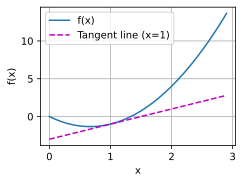

In [96]:
# f(x) = 3*(x**2) - 4*x
# Tangent line at x1=1
# 1. Find the derivade: 6x-4
# 2. Get the slope (evaluete derivade at x1=1): 6(1)-4 = 2 (m=2)
# 3. Evaluate the function at x1=1: 3(1)**2 - 4*1 = -1 (y1=-1)
# 4. Evaluate y−y1 = m(x−x1): y = m(x - x1) + y1 = 2(x - 1) + (-1) = 2x - 3

x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2*x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

#### 2.4.3. Exercises

##### 1. So far we took the rules for derivatives for granted. Using the definition and limits prove the properties for:
    1. $ f(x) = c $
    2. $ f(x) = x^n $
    3. $ f(x) = e^x $
    4. $ f(x) = log(x) $ 

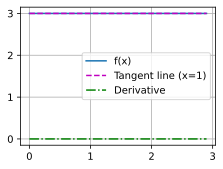

In [97]:
# A. f(x) = c
# Tangent line at x1=1, f(x)=3
# 1. Find the derivade: 0
# 2. Get the slope (evaluete derivade at x1=1): 0 (m=0)
# 3. Evaluate the function at x1=1: 3 (y1=3)
# 4. Evaluate y−y1 = m(x−x1): y = m(x-x1) + y1 = 0(x-1) + 3 = 3
def f(x): return [3]*len(x)
x = np.arange(0, 3, 0.1)

plot(x, [f(x), [3]*len(x), [0]*len(x)], 
     legend=['f(x)', 'Tangent line (x=1)', 'Derivative'])

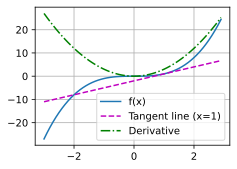

In [98]:
# B. f(x) = x^n
# Tangent line at x1=1, f(x)=X**3
# 1. Find the derivade: 3x**2
# 2. Get the slope (evaluete derivade at x1=1): 3(1)**2 = 3 (m=3)
# 3. Evaluate the function at x1=1: (1)**3 = 1 (y1=1)
# 4. Evaluate y−y1 = m(x−x1): y = m(x-x1) + y1 = 3(x-1) + 1 = 3X - 2
def f(x): return x ** 3
x = np.arange(-3, 3, 0.1)

plot(x, [f(x), 3*x - 2, 3*(x**2)], 
     legend=['f(x)', 'Tangent line (x=1)', 'Derivative'])

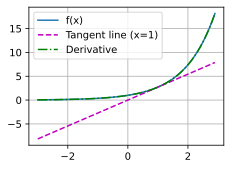

In [99]:
# C. f(x) = e^x
# Tangent line at x1=1, f(x)=e**x
# 1. Find the derivade: e**x
# 2. Get the slope (evaluete derivade at x1=1): np.e**1 = np.e (m=np.e)
# 3. Evaluate the function at x1=1: np.e**1 = np.e (y1=np.e)
# 4. Evaluate y−y1 = m(x−x1): y = m(x-x1) + y1 = np.e(x-1) + np.e = (np.e)X
def f(x): return np.e ** x
x = np.arange(-3, 3, 0.1)

plot(x, [f(x), np.e*x, np.e**x], 
     legend=['f(x)', 'Tangent line (x=1)', 'Derivative'])

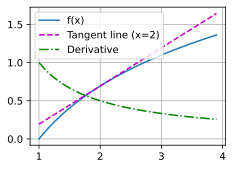

In [100]:
# D. f(x) = log(x) ==> ln(x)
# Tangent line at x1=2, f(x)=ln(x)
# 1. Find the derivade: 1/x
# 2. Get the slope (evaluete derivade at x1=2): 1/2 = 0.5 (m=0.5)
# 3. Evaluate the function at x1=2: log(2) (y1=log(2))
# 4. Evaluate y−y1 = m(x−x1): y = m(x-x1) + y1 = .5(x-2) + log(2) = .5x + log(2) - 1
def f(x): return np.log(x)  # ln = log natural
x = np.arange(1, 4, 0.1)

plot(x, [f(x), .5*x + np.log(2) - 1, 1/x], 
     legend=['f(x)', 'Tangent line (x=2)', 'Derivative'])

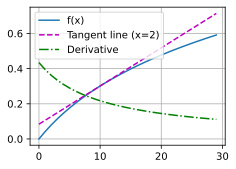

In [101]:
# D. f(x) = log10(x) 
# Tangent line at x1=2, f(x)=log10(x) 
# 1. Find the derivade: 1/(x*ln(10))
# 2. Get the slope (evaluete derivade at x1=2): 1/(2ln(10)) (m=1/(2ln(10)))
# 3. Evaluate the function at x1=2: log10(2) (y1=log10(2))
# 4. Evaluate y−y1 = m(x−x1): y = m(x-x1) + y1 
#                               = (1/(2ln(10)))(x-2) + log10(2)
#                               = (1/(2ln(10)))x - 1/ln(10) + log10(2)
def f(x): return np.log10(x)  # log10
x = np.arange(1, 4, 0.1)

plot([f(x), (1/(2*np.log(10)))*x - 1/np.log(10) + np.log10(2), 1/(x*np.log(10))],
     legend=['f(x)', 'Tangent line (x=2)', 'Derivative'])

##### 2. In the same vein, prove the product, sum, and quotient rule from first principles.

For the sum rule:

\begin{equation}
\begin{split}
&\text{Prove } \frac{d}{dx} \left[ f(x)+g(x) \right] = f'(x) + g'(x) \\
&= \lim_{h \to 0} \frac{[f(x+h)+g(x+h)] - [f(x)+g(x)]}{h} \\
&= \lim_{h \to 0} \frac{f(x+h) - f(x)}{h} + \lim_{h \to 0} \frac{g(x+h) - g(x)}{h} \\
&= \boxed{f'(x) + g'(x)} \\
\end{split}
\end{equation}

For the quotient rule:

\begin{equation}
\begin{split}
&\text{Prove } \frac{d}{dx} \left( \frac{f(x)}{g(x)} \right) = \frac{g(x)f'(x) - f(x)g'(x)}{g^2(x)} \\
&= \lim_{h \to 0} \frac{\frac{f(x+h)}{g(x+h)} - \frac{f(x)}{g(x)}}{h} \\
&= \lim_{h \to 0} \frac{f(x+h)g(x) - f(x)g(x+h)}{hg(x)g(x+h)} \\
&= \lim_{h \to 0} \frac{f(x+h)g(x)-f(x)g(x)+f(x)g(x)-f(x)g(x+h)}{hg(x+h)g(x)} \\
&= \lim_{h \to 0} \frac{g(x)[f(x+h)-f(x)] - f(x)[g(x+h)-g(x)]}{hg(x)g(x+h)} \\
&= \boxed{\frac{f'(x)g(x) - f(x)g'(x)}{g(x)^2}} \\
\end{split}
\end{equation}

##### 3. Prove that the constant multiple rule follows as a special case of the product rule.

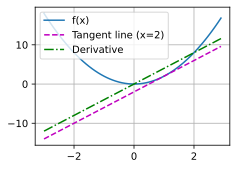

In [102]:
# Tangent line at x1=1, f(x)=(x**2) * 2 
# 1. Find the derivade: 4x
# 2. Get the slope (evaluete derivade at x1=1): 4(1) = 4 (m=4)
# 3. Evaluate the function at x1=1: 2(1)**2 = 2 (y1=2)
# 4. Evaluate y−y1 = m(x−x1): y = m(x-x1) + y1 = 4(x-1) + 2 = 4x - 2
def f(x): return (x**2) * 2
x = np.arange(-3, 3, 0.1)

plot(x, [f(x), 4*x-2, 4*x], legend=['f(x)', 'Tangent line (x=2)', 'Derivative'])

##### 4. Calculate the derivative of $ f(x) = x^x $

Derivative:
$$ f'(x) = x^x \left(ln(x) + 1 \right) $$

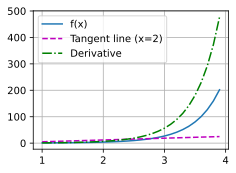

In [103]:
# Tangent line at x1=2, f(x)=(x^x) 
# 1. Find the derivade: (x^x)(ln(x) + 1)
# 2. Get the slope (evaluete derivade at x1=2): (2^2)(ln(2)+1) = 4ln(2) + 4
# 3. Evaluate the function at x1=2: (2^2) = 4 
# 4. Evaluate y−y1 = m(x−x1): y = m(x-x1) + y1 → (4ln(2)+4)(x-2) + 4
#                                                4ln(2)x - 8ln(2) + 4x -8 + 4
#                                                4x(ln(2)+1) + 4(1-2ln(2))
def f(x): return (x**x)                       # Original function
def g(x): return (x**x) * (np.log(x) + 1)     # Derivate
def h(x): return 4*x*(np.log(2)+1) + 4*(1-(2*np.log(2)))   # Tangent at x=2
x = np.arange(1, 4, 0.1)


plot(x, [f(x), h(x), g(x)], legend=['f(x)', 'Tangent line (x=2)', 'Derivative'])

##### 5. What does it mean that $ f'(x) = 0 $ for some `x`? Give an example of a function `f` and a location `x` for which this might hold.

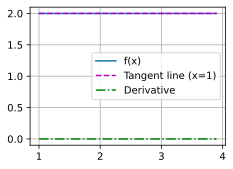

In [104]:
# Tangent line at x1=1, f(x)=2
# 1. Find the derivade: 0
# 2. Get the slope (evaluete derivade at x1=1): 0
# 3. Evaluate the function at x1=1: 2
# 4. Evaluate y−y1 = m(x−x1): y = m(x-x1) + y1 → 0(x-2) + 2 = 2
def f(x): return [2]*len(x)     # Original function
def g(x): return [0]*len(x)     # Derivate
def h(x): return [2]*len(x)     # Tangent at x=1
x = np.arange(1, 4, 0.1)


plot(x, [f(x), h(x), g(x)], legend=['f(x)', 'Tangent line (x=1)', 'Derivative'])

##### 6. Plot the function $ y = f(x) = x^3 - \frac{1}{x} $ and plot its tangent line at $ x = 1 $.

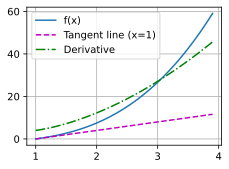

In [105]:
# Tangent line at x1=1, f(x)=x^3 - 1/x
# 1. Find the derivade: 3x^2 + 1/x^2
# 2. Get the slope (evaluete derivade at x1=1): 3(1^2) + 1/(1^2) = 4
# 3. Evaluate the function at x1=1: (1^3) - 1/1 = 0
# 4. Evaluate y−y1 = m(x−x1): y = m(x-x1) + y1 → 4(x-1)+0 = 4x - 4
def f(x): return (x**3) - (1/x)              # Original function
def g(x): return (3*(x**2)) + (1/(x**2))     # Derivate
def h(x): return (4*x) - 4                   # Tangent at x=1
x = np.arange(1, 4, 0.1)

plot(x, [f(x), h(x), g(x)], legend=['f(x)', 'Tangent line (x=1)', 'Derivative'])

##### 7. Find the gradient of the function $ f(x) = 3x^2_1 + 5e^{x_2} $

$$
\nabla_x f(x) =
\begin{bmatrix}
  6x_1 \\
  5e^{x_2} \\
\end{bmatrix}
$$

##### 8. What is the gradient of the function $ f(x) = \parallel x \parallel_2 $? What happens for $ x= 0 $?

**Answer:**

\begin{equation}
\begin{split}
  f(\mathbf{x}) &= \|\mathbf{x}\|_2 \\
  \nabla_{\mathbf{x}} \|\mathbf{x}\|_2 &= \nabla_{\mathbf{x}} (\mathbf{x}^{\top}\mathbf{x})^{1/2} \\
  &= 2\mathbf{x} \cdot \frac{1}{2}(\mathbf{x}^{\top}\mathbf{x})^{-1/2} \\
  &= \boxed{\frac{\mathbf{x}}{\|\mathbf{x}\|_2}} \\
\end{split}
\end{equation}

At $ x=0 $, the gradient is undefined.

**More detail provided in answer:**

The function $ f(x) = \parallel x \parallel_2 $ represents the Euclidean norm (or 2-norm) of a vector $ 𝑥 $, which is defined as:

$$ f(x) = \parallel x \parallel_2 = \sqrt{ x^2_1 + X^2_2 + ... + x^2_n} $$

where $ x = (x_1, x_2, ..., x_n) \in ℝ $

To compute the gradient of $ f(x) $, we need to differentiate it with respect to each component of the vector $ x $. The gradient $ \nabla_x f(x) $ is the vector of partial derivatives of $ f(x) $ with respect to each $ x_i $.

We have:

$$ f(x) = \parallel x \parallel_2 = \sqrt{ x^2_1 + X^2_2 + ... + x^2_n} $$

This is equivalent to:

$$ f(x) = \parallel x \parallel_2 = \sqrt{ x^T x} $$

The gradient of $ f(x) $ can be computed as :
1. The derivative of $ \sqrt{ x^T x} $ with respect to $ x $ is:
$$ \nabla_x f(x) = \frac{d}{dx} ( \sqrt{ x^T x} ) $$

2. Applying the chain rule, we differentiate the square root:
$$ \nabla_x f(x) = \frac{1}{2}(x^T x)^{\frac{1}{2}} . 2x $$

3. Simplifying:
$$ \nabla_x f(x) = \frac{x}{\parallel x \parallel_2} $$

So, the gradient of $ f(x) = \parallel x \parallel_2 $ is:
$$ \nabla_x f(x) = \frac{x}{\parallel x \parallel_2} $$

This means the gradient points in the direction of $ 𝑥 $ and its magnitude is normalized by the norm of $ 𝑥 $.

##### 9. Can you write out the chain rule for the case where $ u = f(x, y, z) $ and  $ x = x(a, b) $, and $ y = y(a, b) $, and $ z = z(a, b) $?

$$
\frac{\partial{u}}{\partial{a}} = \frac{\partial{u}}{\partial{x}} \cdot \frac{\partial{x}}{\partial{a}} + \frac{\partial{u}}{\partial{y}} \cdot \frac{\partial{y}}{\partial{a}} + \frac{\partial{u}}{\partial{z}} \cdot \frac{\partial{z}}{\partial{a}}
$$

##### 10. Given a function  $ f(x) $ that is invertible, compute the derivative of its inverse  $ f^{-1}(x) $. Here we have that $ f^{-1}(f(x)) $ and conversely $ f(f^{-1}(y)) = y $. Hint: use these properties in your derivation.

\begin{equation}
\begin{split}
y &= f^{-1}(x) \\
x &= f(y) \\
1 &= f'(y) \cdot \frac{dy}{dx} \\
\frac{dy}{dx} &= \frac{1}{f'(y)} \\
\frac{d}{dx}f^{-1}(x) &= \frac{1}{f'(f^{-1}(x))} \\
\end{split}
\end{equation}

### 2.5. Automatic Differentiation

#### 2.5.1. A Simple Function
Let’s assume that we are interested in differentiating the function $ y = 2x^T x $ with respect to the column vector $ x $. To start, we assign $ x $ an initial value.

In [106]:
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [107]:
# Can also create x = torch.arange(4.0, requires_grad=True)
x.requires_grad_(True)
x.grad  # The gradient is None by default

In [108]:
# We now calculate our function of x and assign the result to y.
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [109]:
# We can now take the gradient of y with respect to x by calling its backward method. 
# Next, we can access the gradient via x’s grad attribute.
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [110]:
# We already know that the gradient of the function `y = 2x.x = 2x^2` with 
# respect to `x` should be `4x`.
# We can now verify that the automatic gradient computation and the expected 
# result are identical.
x.grad == 4 * x

tensor([True, True, True, True])

In [111]:
# Now let’s calculate another function of x and take its gradient.
# Note that PyTorch does not automatically reset the gradient buffer
# when we record a new gradient.
# Instead, the new gradient is added to the already-stored gradient. 
# This behavior comes in handy when we want to optimize the sum of 
y = x.sum()
y.backward()
x.grad

tensor([ 1.,  5.,  9., 13.])

In [112]:
# multiple objective functions. 
# To reset the gradient buffer, we can call x.grad.zero_() as follows:
x.grad.zero_()  # Reset the gradient
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

#### 2.5.2. Backward for Non-Scalar Variables

In [113]:
# The gradient of the function `y = x.x = x^2` with is `2x`.
x.grad.zero_()
y = x * x
y.backward(gradient=torch.ones(len(y)))  # Faster: y.sum().backward()
print(x)
print(x.grad)

tensor([0., 1., 2., 3.], requires_grad=True)
tensor([0., 2., 4., 6.])


#### 2.5.3. Detaching Computation

In PyTorch, the `detach()` method is used to create a new tensor that shares the same data as the original tensor but without tracking gradients. This is useful when you want to stop a tensor from being part of the computation graph for gradient calculations, typically in scenarios where you need a tensor's value but don't want to affect the autograd mechanism.

In [114]:
x.grad.zero_()
y = x * x
u = y  # No `.detach` applied
z = u * x

z.sum().backward()
print(f'''
          x: {x}
          y: {y}
          u: {u}
     x.grad: {x.grad}
x.grad == u: {x.grad == u}
          z: {z}
''')


          x: tensor([0., 1., 2., 3.], requires_grad=True)
          y: tensor([0., 1., 4., 9.], grad_fn=<MulBackward0>)
          u: tensor([0., 1., 4., 9.], grad_fn=<MulBackward0>)
     x.grad: tensor([ 0.,  3., 12., 27.])
x.grad == u: tensor([ True, False, False, False])
          z: tensor([ 0.,  1.,  8., 27.], grad_fn=<MulBackward0>)



In [115]:
x.grad.zero_()
y = x * x
u = y.detach()  # Returns a new Tensor, detached from the current graph.
z = u * x

z.sum().backward()
print(f'''
          x: {x}
          y: {y}
          u: {u}
     x.grad: {x.grad}
x.grad == u: {x.grad == u}
          z: {z}
''')


          x: tensor([0., 1., 2., 3.], requires_grad=True)
          y: tensor([0., 1., 4., 9.], grad_fn=<MulBackward0>)
          u: tensor([0., 1., 4., 9.])
     x.grad: tensor([0., 1., 4., 9.])
x.grad == u: tensor([True, True, True, True])
          z: tensor([ 0.,  1.,  8., 27.], grad_fn=<MulBackward0>)



In [116]:
# Note that while this procedure detaches y’s ancestors from the graph leading to z,
# the computational graph leading to y persists and thus we can calculate the gradient
# of y with respect to x.
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True])

#### 2.5.4. Gradients and Python Control Flow

In [117]:
print(x)
print(np.sqrt(0+1+4+9))      # √∑xᵢ² 
torch.linalg.vector_norm(x)  # Computes a vector norm.

tensor([0., 1., 2., 3.], requires_grad=True)
3.7416573867739413


tensor(3.7417, grad_fn=<LinalgVectorNormBackward0>)

In [118]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [119]:
# Below, we call this function, passing in a random value, as input. 
# Since the input is a random variable, we do not know what form the 
# computational graph will take. However, whenever we execute f(a) on a 
# specific input, we realize a specific computational graph and can 
# subsequently run backward.
a = torch.randn(size=(), requires_grad=True)
print(a)
d = f(a)
print(d)
d.backward()

tensor(1.2858, requires_grad=True)
tensor(1316.6554, grad_fn=<MulBackward0>)


In [120]:
print(a.grad)
print(d/a)
a.grad == d / a

tensor(1024.)
tensor(1024., grad_fn=<DivBackward0>)


tensor(True)

### 2.6. Probability and Statistics

#### 2.6.1. A Simple Example: Tossing Coins

In [121]:
num_tosses = 100
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - heads
print("heads, tails: ", [heads, tails])

heads, tails:  [52, 48]


In [122]:
fair_probs = torch.tensor([0.5, 0.5])
Multinomial(100, fair_probs).sample()

tensor([47., 53.])

In [123]:
Multinomial(100, fair_probs).sample() / 100

tensor([0.5300, 0.4700])

In [124]:
counts = Multinomial(10000, fair_probs).sample()
counts / 10000

tensor([0.5037, 0.4963])

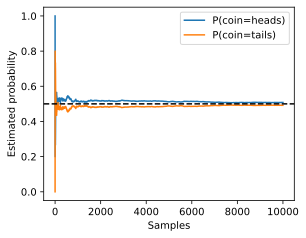

In [125]:
counts = Multinomial(1, fair_probs).sample((10000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()

d2l.set_figsize((4.5, 3.5))
d2l.plt.plot(estimates[:, 0], label=("P(coin=heads)"))
d2l.plt.plot(estimates[:, 1], label=("P(coin=tails)"))
d2l.plt.axhline(y=0.5, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Samples')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();

#### 2.6.2. Exercises

Give an example where observing more data can reduce the amount of uncertainty about the outcome to an arbitrarily low level.

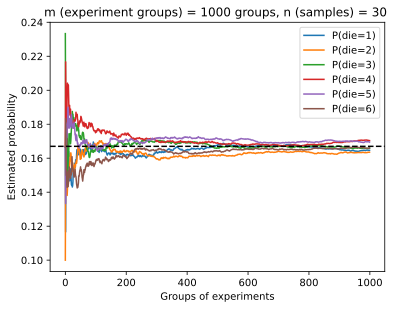

In [126]:
def experiment_fig(n, m):
    fair_probs = torch.tensor([1/6]* 6 )
    counts = torch.from_numpy(np.random.multinomial(n, fair_probs, size=m))
    cum_counts = counts.type(torch.float32).cumsum(axis=0)
    estimates = cum_counts / cum_counts.sum(axis=1, keepdims=True)
    d2l.set_figsize((6, 4.5))
    for i in range(6):
        d2l.plt.plot(estimates[:, i].numpy(),
                    label=("P(die=" + str(i + 1) + ")"))
    d2l.plt.axhline(y=0.167, color='black', linestyle='dashed')
    d2l.plt.gca().set_xlabel('Groups of experiments')
    d2l.plt.gca().set_ylabel('Estimated probability')
    d2l.plt.title(f'm (experiment groups) = {m} groups, n (samples) = {n} ')
    d2l.plt.legend()
experiment_fig(30, 1000)

-------------------------------------